# 02 Default Probability Model

## Credit Risk Basket CDS Pricing

### Objective

The objective of this notebook is to estimate the default probability term structure for each reference entity.

The estimated default probabilities will later be used in the Gaussian Copula model to simulate correlated default times for Basket CDS pricing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2 Load Historical Market Data

The historical adjusted closing prices collected in Notebook 01 are loaded.

Although the default probability estimation in this notebook is based on CDS spreads, loading the market data ensures a consistent workflow across the project.

In [3]:
prices = pd.read_csv("../Data/bank_prices.csv", index_col=0)

prices.head()

,BAC,C,GS,JPM,MS
Date,,,,,
2023-01-03,30.640949,40.644218,318.011597,123.735207,76.617455
2023-01-04,31.217012,41.691841,319.371124,124.889008,77.448700
2023-01-05,31.152998,41.505405,315.752106,124.861366,76.796211
2023-01-06,31.463890,42.002571,319.720154,127.250633,78.262054
2023-01-09,30.988411,42.206779,324.239227,126.724785,78.333572


## Step 3 Define CDS Market Spreads

Real CDS market spreads are generally obtained from Bloomberg or Refinitiv.

Since these proprietary datasets are unavailable for this project, representative market spreads are assumed for demonstration purposes.

These assumptions are used consistently throughout the project.

In [4]:
cds_spreads = pd.DataFrame({
    "Bank": ["JPM", "BAC", "C", "GS", "MS"],
    "Spread_bps": [60, 75, 85, 70, 80]
})

cds_spreads

,Bank,Spread_bps
0,JPM,60
1,BAC,75
2,C,85
3,GS,70
4,MS,80


## Step 4 Assume Recovery Rate

A constant recovery rate of 40% is assumed.

This assumption is widely adopted in academic literature and market practice for senior unsecured corporate debt.

In [5]:
recovery_rate = 0.40

## Step 5 Estimate Hazard Rates

Under a simplified reduced-form credit model, the hazard rate is approximated as:

Hazard Rate = CDS Spread / (1 − Recovery Rate)

This approximation provides an estimate of the instantaneous default intensity.

In [6]:
cds_spreads["Spread"] = cds_spreads["Spread_bps"] / 10000

cds_spreads["Hazard_Rate"] = (
    cds_spreads["Spread"] /
    (1 - recovery_rate)
)

cds_spreads

,Bank,Spread_bps,Spread,Hazard_Rate
0,JPM,60,0.0060,0.010000
1,BAC,75,0.0075,0.012500
2,C,85,0.0085,0.014167
3,GS,70,0.0070,0.011667
4,MS,80,0.0080,0.013333


## Step 6 Calculate Survival Probability

The survival probability represents the probability that a reference entity survives without default up to a future time.

Under the constant hazard rate assumption, the survival probability is:

S(t)=exp(-λt)

where:

- λ is the hazard rate
- t is time in years

Survival probabilities decrease over time as the likelihood of default accumulates.

In [7]:
years = np.arange(1, 6)

survival = pd.DataFrame(index=years)

for _, row in cds_spreads.iterrows():
    survival[row["Bank"]] = np.exp(
        -row["Hazard_Rate"] * years
    )

survival

,JPM,BAC,C,GS,MS
1,0.990050,0.987578,0.985933,0.988401,0.986755
2,0.980199,0.975310,0.972064,0.976937,0.973686
3,0.970446,0.963194,0.958390,0.965605,0.960789
4,0.960789,0.951229,0.944909,0.954405,0.948064
5,0.951229,0.939413,0.931617,0.943335,0.935507


## Step 7 Calculate Default Probability

The cumulative default probability is obtained from the survival probability.

Default Probability = 1 − Survival Probability

This represents the probability that default occurs before a given time horizon.

In [8]:
default_probability = 1 - survival

default_probability

,JPM,BAC,C,GS,MS
1,0.009950,0.012422,0.014067,0.011599,0.013245
2,0.019801,0.024690,0.027936,0.023063,0.026314
3,0.029554,0.036806,0.041610,0.034395,0.039211
4,0.039211,0.048771,0.055091,0.045595,0.051936
5,0.048771,0.060587,0.068383,0.056665,0.064493


## Step 8 Visualize Survival Probability

The survival curves illustrate how the probability of remaining solvent declines over time for each reference entity.

Banks with higher hazard rates exhibit steeper declines in survival probability.

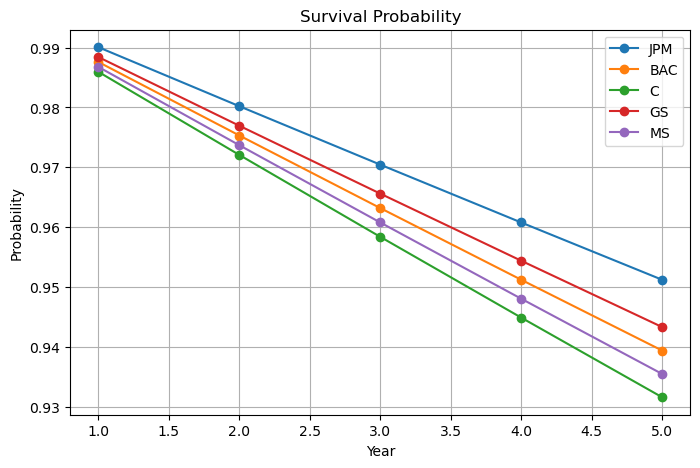

In [9]:
plt.figure(figsize=(8,5))

for bank in survival.columns:
    plt.plot(
        survival.index,
        survival[bank],
        marker='o',
        label=bank
    )

plt.title("Survival Probability")
plt.xlabel("Year")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)

plt.show()

## Step 9 Visualize Default Probability

The cumulative default probability increases over time.

These probabilities will later be transformed into default times using the Gaussian Copula model.

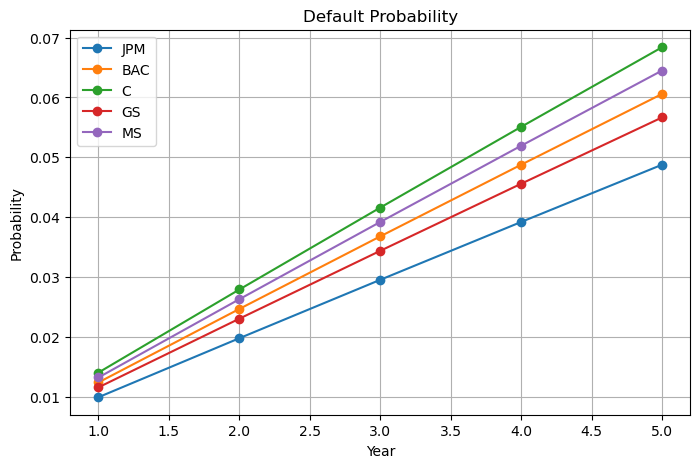

In [10]:
plt.figure(figsize=(8,5))

for bank in default_probability.columns:
    plt.plot(
        default_probability.index,
        default_probability[bank],
        marker='o',
        label=bank
    )

plt.title("Default Probability")
plt.xlabel("Year")
plt.ylabel("Probability")

plt.legend()
plt.grid(True)

plt.show()

# Business Interpretation

The estimated hazard rates indicate the relative credit risk of each reference entity.

A higher hazard rate leads to:

- Lower survival probability
- Higher cumulative default probability
- Higher expected loss
- Higher Basket CDS premium

These estimated default probabilities provide the key inputs for the Gaussian Copula model developed in the next notebook.

# Summary

In this notebook we:

- Defined market CDS spreads
- Assumed a recovery rate
- Estimated hazard rates
- Calculated survival probabilities
- Calculated cumulative default probabilities
- Visualized both probability curves

These outputs form the credit risk inputs required for the correlation modeling stage.